In [132]:
# Banking Customer Analytics
# Exploring customer behavior and marketing campaign outcomes

import numpy as np
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


In [133]:
# Load the banking dataset

df = pd.read_csv('/content/bank.csv', sep=';')

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Rows: 4521
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [134]:
# Inspect the dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(4521, 17)

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate Rows:
0


In [135]:
# Descriptive statistics for numerical variables

print("NUMERICAL SUMMARY")
display(df.describe())

print("\nSUBSCRIPTION OUTCOME")
print(df['y'].value_counts())

print("\nSUBSCRIPTION RATE (%)")
print(df['y'].value_counts(normalize=True).mul(100).round(2))

print("\nJOB DISTRIBUTION")
print(df['job'].value_counts())

print("\nEDUCATION DISTRIBUTION")
print(df['education'].value_counts())

print("\nMARITAL STATUS DISTRIBUTION")
print(df['marital'].value_counts())

NUMERICAL SUMMARY


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000



SUBSCRIPTION OUTCOME
y
no     4000
yes     521
Name: count, dtype: int64

SUBSCRIPTION RATE (%)
y
no     88.48
yes    11.52
Name: proportion, dtype: float64

JOB DISTRIBUTION
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

EDUCATION DISTRIBUTION
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

MARITAL STATUS DISTRIBUTION
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64


In [136]:
# Customer segment subscription analysis

# Create numeric subscription indicator
df['subscribed'] = df['y'].map({'yes': 1, 'no': 0})

# Subscription rate by job
job_analysis = (
    df.groupby('job')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

job_analysis['subscription_rate'] = (
    job_analysis['subscription_rate'] * 100
).round(2)

job_analysis = job_analysis.sort_values(
    'subscription_rate',
    ascending=False
)

print("SUBSCRIPTION RATE BY JOB")
display(job_analysis)

# Subscription rate by education
education_analysis = (
    df.groupby('education')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

education_analysis['subscription_rate'] = (
    education_analysis['subscription_rate'] * 100
).round(2)

education_analysis = education_analysis.sort_values(
    'subscription_rate',
    ascending=False
)

print("\nSUBSCRIPTION RATE BY EDUCATION")
display(education_analysis)

# Subscription rate by marital status
marital_analysis = (
    df.groupby('marital')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

marital_analysis['subscription_rate'] = (
    marital_analysis['subscription_rate'] * 100
).round(2)

marital_analysis = marital_analysis.sort_values(
    'subscription_rate',
    ascending=False
)

print("\nSUBSCRIPTION RATE BY MARITAL STATUS")
display(marital_analysis)

SUBSCRIPTION RATE BY JOB


,customers,subscriptions,subscription_rate
job,,,
retired,230,54,23.48
student,84,19,22.62
unknown,38,7,18.42
management,969,131,13.52
housemaid,112,14,12.50
admin.,478,58,12.13
self-employed,183,20,10.93
technician,768,83,10.81
unemployed,128,13,10.16



SUBSCRIPTION RATE BY EDUCATION


,customers,subscriptions,subscription_rate
education,,,
tertiary,1350,193,14.30
secondary,2306,245,10.62
unknown,187,19,10.16
primary,678,64,9.44



SUBSCRIPTION RATE BY MARITAL STATUS


,customers,subscriptions,subscription_rate
marital,,,
divorced,528,77,14.58
single,1196,167,13.96
married,2797,277,9.90


In [137]:
# Banking characteristics and subscription behavior

print("AVERAGE CUSTOMER CHARACTERISTICS BY SUBSCRIPTION")
customer_comparison = (
    df.groupby('y')[['age', 'balance', 'campaign', 'previous']]
    .mean()
    .round(2)
)

display(customer_comparison)


print("\nSUBSCRIPTION RATE BY HOUSING LOAN")
housing_analysis = (
    df.groupby('housing')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

housing_analysis['subscription_rate'] = (
    housing_analysis['subscription_rate'] * 100
).round(2)

display(housing_analysis)


print("\nSUBSCRIPTION RATE BY PERSONAL LOAN")
loan_analysis = (
    df.groupby('loan')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

loan_analysis['subscription_rate'] = (
    loan_analysis['subscription_rate'] * 100
).round(2)

display(loan_analysis)


print("\nSUBSCRIPTION RATE BY DEFAULT STATUS")
default_analysis = (
    df.groupby('default')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

default_analysis['subscription_rate'] = (
    default_analysis['subscription_rate'] * 100
).round(2)

display(default_analysis)

AVERAGE CUSTOMER CHARACTERISTICS BY SUBSCRIPTION


,age,balance,campaign,previous
y,,,,
no,41.00,1403.21,2.86,0.47
yes,42.49,1571.96,2.27,1.09



SUBSCRIPTION RATE BY HOUSING LOAN


,customers,subscriptions,subscription_rate
housing,,,
no,1962,301,15.34
yes,2559,220,8.60



SUBSCRIPTION RATE BY PERSONAL LOAN


,customers,subscriptions,subscription_rate
loan,,,
no,3830,478,12.48
yes,691,43,6.22



SUBSCRIPTION RATE BY DEFAULT STATUS


,customers,subscriptions,subscription_rate
default,,,
no,4445,512,11.52
yes,76,9,11.84


In [138]:
# Previous campaign analysis

print("SUBSCRIPTION RATE BY PREVIOUS CAMPAIGN OUTCOME")

previous_outcome = (
    df.groupby('poutcome')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

previous_outcome['subscription_rate'] = (
    previous_outcome['subscription_rate'] * 100
).round(2)

previous_outcome = previous_outcome.sort_values(
    'subscription_rate',
    ascending=False
)

display(previous_outcome)


print("\nCUSTOMERS WITH VS. WITHOUT PREVIOUS CONTACT")

df['previously_contacted'] = np.where(
    df['previous'] > 0,
    'Previously Contacted',
    'No Previous Contact'
)

previous_contact = (
    df.groupby('previously_contacted')['subscribed']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'customers',
        'sum': 'subscriptions',
        'mean': 'subscription_rate'
    })
)

previous_contact['subscription_rate'] = (
    previous_contact['subscription_rate'] * 100
).round(2)

display(previous_contact)

SUBSCRIPTION RATE BY PREVIOUS CAMPAIGN OUTCOME


,customers,subscriptions,subscription_rate
poutcome,,,
success,129,83,64.34
other,197,38,19.29
failure,490,63,12.86
unknown,3705,337,9.10



CUSTOMERS WITH VS. WITHOUT PREVIOUS CONTACT


,customers,subscriptions,subscription_rate
previously_contacted,,,
No Previous Contact,3705,337,9.10
Previously Contacted,816,184,22.55


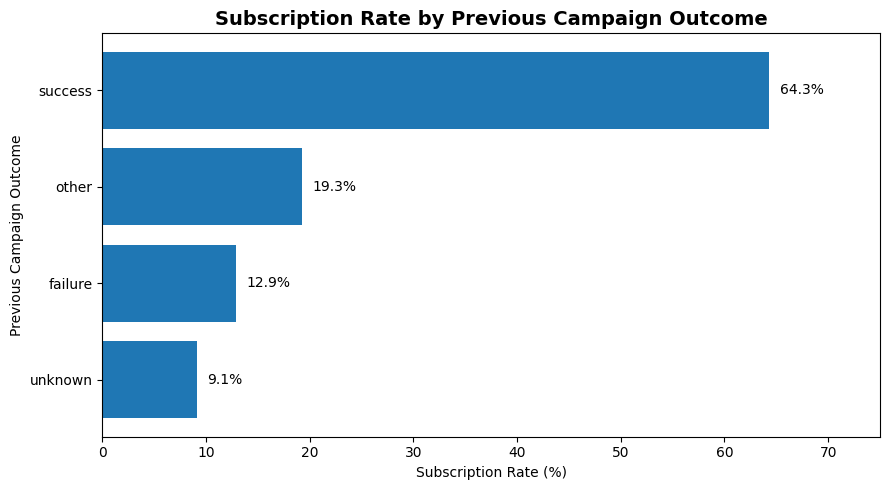

In [139]:
# Visualization 1: Subscription Rate by Previous Campaign Outcome

import matplotlib.pyplot as plt

plot_data = previous_outcome.sort_values(
    'subscription_rate',
    ascending=True
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_data.index,
    plot_data['subscription_rate']
)

plt.title(
    'Subscription Rate by Previous Campaign Outcome',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Subscription Rate (%)')
plt.ylabel('Previous Campaign Outcome')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center'
    )

plt.xlim(0, 75)
plt.tight_layout()
plt.show()

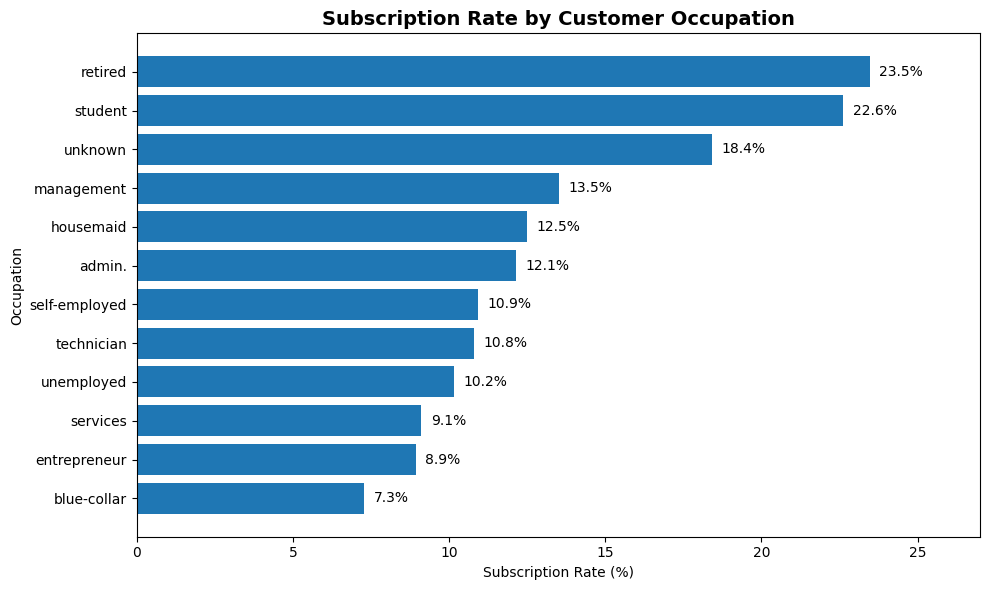

In [140]:
# Visualization 2: Subscription Rate by Job

job_plot = job_analysis.sort_values(
    'subscription_rate',
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    job_plot.index,
    job_plot['subscription_rate']
)

plt.title(
    'Subscription Rate by Customer Occupation',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Subscription Rate (%)')
plt.ylabel('Occupation')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center'
    )

plt.xlim(0, 27)
plt.tight_layout()
plt.show()

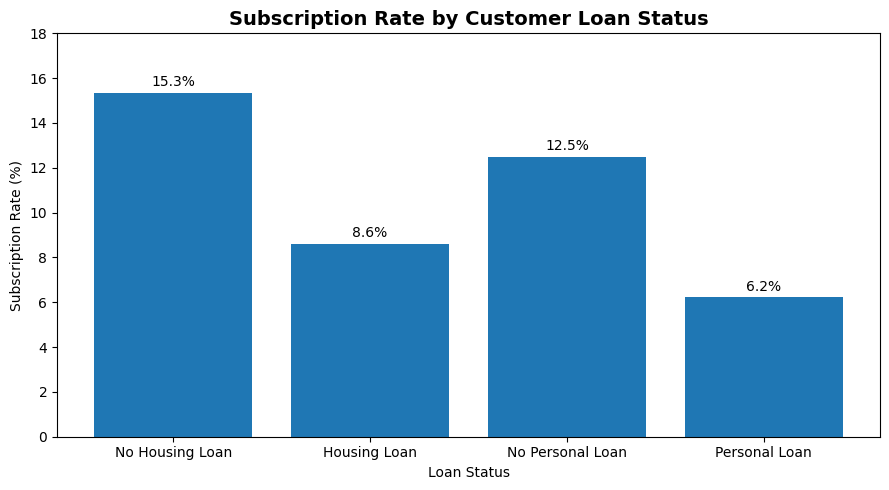

In [141]:
# Visualization 3: Subscription Rate by Loan Status

loan_comparison = pd.DataFrame({
    'No Housing Loan': [housing_analysis.loc['no', 'subscription_rate']],
    'Housing Loan': [housing_analysis.loc['yes', 'subscription_rate']],
    'No Personal Loan': [loan_analysis.loc['no', 'subscription_rate']],
    'Personal Loan': [loan_analysis.loc['yes', 'subscription_rate']]
}).T

loan_comparison.columns = ['subscription_rate']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    loan_comparison.index,
    loan_comparison['subscription_rate']
)

plt.title(
    'Subscription Rate by Customer Loan Status',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Subscription Rate (%)')
plt.xlabel('Loan Status')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center'
    )

plt.ylim(0, 18)
plt.tight_layout()
plt.show()


## Key Findings

The exploratory analysis identified several notable patterns in customer subscription behavior:

- **Overall subscription rate:** 11.5% of customers in the dataset subscribed to the term deposit.

- **Previous campaign performance was strongly associated with subscription behavior.** Customers whose previous campaign outcome was successful had a 64.3% subscription rate, compared with 12.9% following a previous failure and 9.1% for customers with an unknown previous outcome.

- **Subscription rates varied substantially by occupation.** Retired customers had the highest observed subscription rate at 23.5%, followed by students at 22.6%. Blue-collar customers had the lowest observed rate at 7.3%.

- **Customers without loans showed higher subscription rates.** Customers without housing loans subscribed at 15.3%, compared with 8.6% among customers with housing loans. Customers without personal loans subscribed at 12.5%, compared with 6.2% among customers with personal loans.

These findings suggest that previous campaign outcomes, customer occupation, and existing loan status may be useful factors when developing customer segments and evaluating marketing strategies.

## Business Recommendations

Based on the exploratory findings, a financial institution could consider:

1. **Prioritizing previously responsive customers** when designing follow-up campaigns, while continuing to evaluate whether the strong historical relationship persists in new campaign data.

2. **Testing targeted strategies across occupational segments**, particularly groups that demonstrated higher subscription rates such as retired customers and students.

3. **Considering existing loan relationships during customer segmentation**, since customers without housing or personal loans demonstrated higher subscription rates in this dataset.

4. **Using predictive modeling as a next step** to evaluate multiple customer and campaign characteristics simultaneously and identify which factors provide the strongest predictive value.

These recommendations are exploratory and should be validated through additional statistical analysis, modeling, and campaign testing before implementation.

## Predictive Modeling

To extend the exploratory analysis, I developed a classification model to predict whether a customer would subscribe to a term deposit.

Logistic regression was selected as the initial model because the target variable has two outcomes: subscribed (`yes`) or did not subscribe (`no`). Categorical variables are encoded before modeling, and the dataset is divided into training and testing sets to evaluate performance on unseen data.

In [142]:
# Prepare data for predictive modeling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Separate predictors and target
X = df.drop(columns='y')
y = df['y'].map({'no': 0, 'yes': 1})

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

print("Categorical features:", list(categorical_features))
print("Numerical features:", list(numerical_features))
print("\nTarget distribution:")
print(y.value_counts())

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'previously_contacted']
Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'subscribed']

Target distribution:
y
0    4000
1     521
Name: count, dtype: int64


In [143]:
# Remove analysis-only columns to prevent data leakage

columns_to_remove = [
    'y',
    'subscribed',
    'previously_contacted'
]

X = df.drop(
    columns=[col for col in columns_to_remove if col in df.columns]
)

y = df['y'].map({'no': 0, 'yes': 1})

# Identify categorical and numerical features again
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (3616, 16)
Testing set: (905, 16)

Training target distribution:
y
0    3199
1     417
Name: count, dtype: int64

Testing target distribution:
y
0    801
1    104
Name: count, dtype: int64


In [144]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_features
        )
    ]
)

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ]
)

# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [145]:
# Make predictions on the test data
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE")
print("-----------------")
print(f"Accuracy: {accuracy:.2%}")
print(f"ROC-AUC Score: {roc_auc:.3f}")

print("\nCLASSIFICATION REPORT")
print("---------------------")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Subscription", "Subscription"]
))

print("\nCONFUSION MATRIX")
print("----------------")
print(confusion_matrix(y_test, y_pred))

MODEL PERFORMANCE
-----------------
Accuracy: 82.32%
ROC-AUC Score: 0.891

CLASSIFICATION REPORT
---------------------
                 precision    recall  f1-score   support

No Subscription       0.97      0.83      0.89       801
   Subscription       0.37      0.78      0.50       104

       accuracy                           0.82       905
      macro avg       0.67      0.80      0.70       905
   weighted avg       0.90      0.82      0.85       905


CONFUSION MATRIX
----------------
[[664 137]
 [ 23  81]]


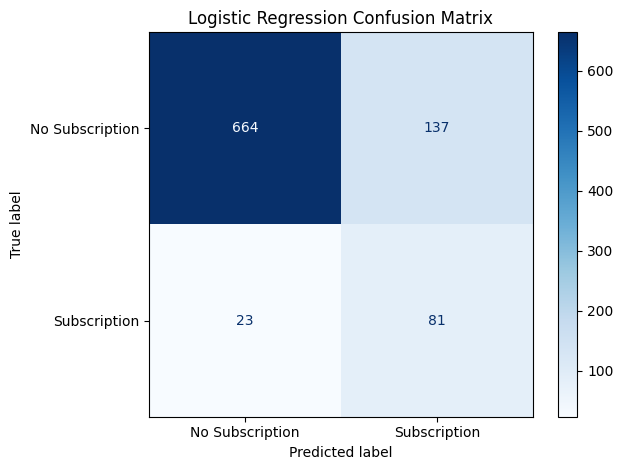

In [146]:
# Visualize the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Subscription", "Subscription"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

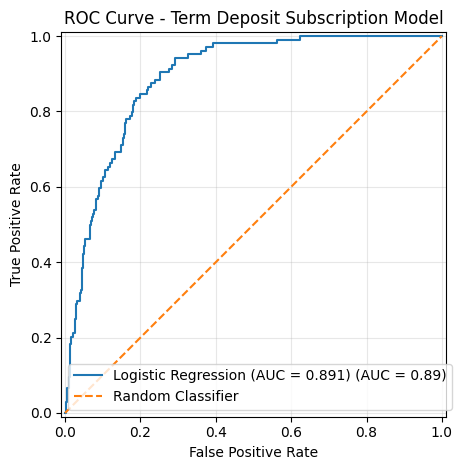

In [147]:
# Plot ROC Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve - Term Deposit Subscription Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Evaluation

A logistic regression classification model was developed to explore whether customer and campaign characteristics could be used to identify customers more likely to subscribe to a term deposit.

The model achieved:

- **Accuracy:** 82.3%
- **ROC-AUC:** 0.891
- **Subscriber Recall:** 78%
- **Subscriber Precision:** 37%
- **Subscriber F1-Score:** 0.50

The ROC-AUC score indicates that the model demonstrated strong ability to distinguish between customers who subscribed and those who did not.

Of the 104 customers in the test set who actually subscribed, the model correctly identified **81**, representing approximately **78% of actual subscribers**.

However, the model also classified 137 non-subscribers as potential subscribers. This resulted in lower precision for the subscriber class and demonstrates an important business tradeoff: the model captures a large portion of potential subscribers but would also result in outreach to customers who may not ultimately subscribe.

For a marketing campaign, this model could serve as an initial customer-targeting tool. Further model tuning, feature engineering, threshold optimization, and comparison with additional classification algorithms could potentially improve precision while maintaining strong recall.

### Business Interpretation

The predictive results complement the exploratory analysis by demonstrating that customer and campaign characteristics contain useful information for identifying potential subscribers. Rather than contacting customers without prioritization, a financial institution could use predictive analytics to rank customers by likelihood of subscription and focus campaign resources on higher-potential segments.